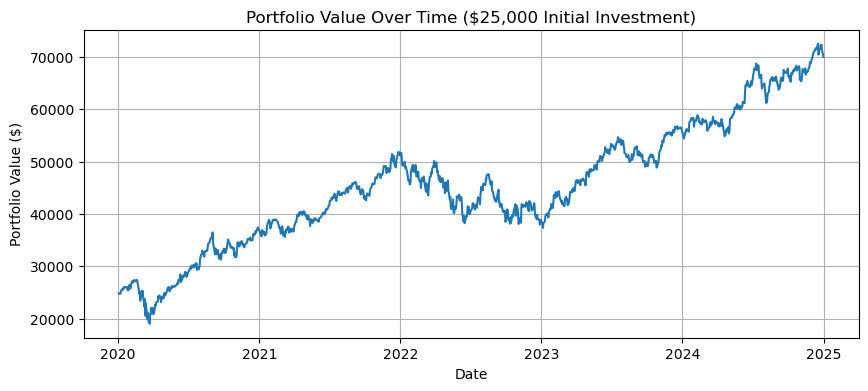

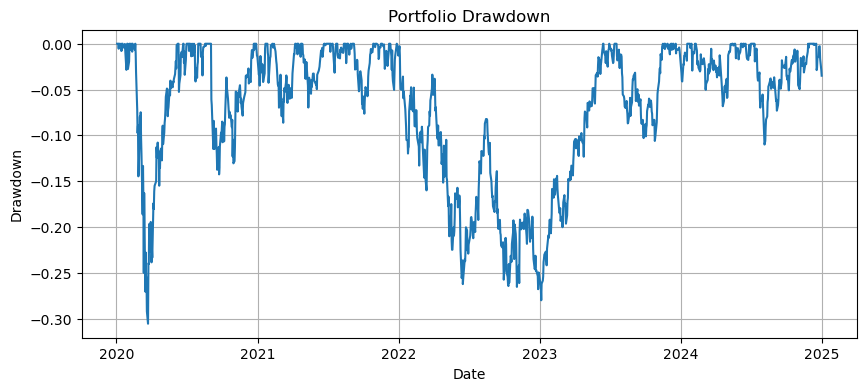

Investment Recommendation:
- Balanced risk profile: maintain diversified exposure and monitor portfolio risk.

Investment Growth Summary:


,Initial Investment ($),Final Portfolio Value ($),Total Gain ($),Total Return (%)
0,25000,70023.5,45023.5,180.09


Portfolio Risk Summary:


,Annualized Return,Annualized Volatility,Max Drawdown,Beta vs SPY,Observations (daily)
0,0.240528,0.260403,-0.305559,1.134942,1257


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# -----------------------------
# 1) USER INPUTS
# -----------------------------
tickers = ["AAPL", "MSFT", "SPY"]
weights = np.array([0.40, 0.30, 0.30])
start_date = "2020-01-01"
end_date = "2025-01-01"

initial_investment = 25000
risk_tolerance = "Medium"  # Low, Medium, High

# -----------------------------
# 2) VALIDATION
# -----------------------------
if len(weights) != len(tickers):
    raise ValueError("Weights must match number of tickers.")

weights = weights / weights.sum()  # normalize just in case

# -----------------------------
# 3) DOWNLOAD PRICE DATA (ROBUST)
# -----------------------------
data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    progress=False,
    auto_adjust=False
)

if isinstance(data.columns, pd.MultiIndex):
    if "Adj Close" in data.columns.get_level_values(0):
        prices = data["Adj Close"]
    else:
        prices = data["Close"]
else:
    prices = data["Adj Close"] if "Adj Close" in data.columns else data["Close"]

prices = prices.reindex(columns=tickers).dropna()

# -----------------------------
# 4) RETURNS & PORTFOLIO VALUE
# -----------------------------
returns = prices.pct_change().dropna()
portfolio_returns = returns @ weights

portfolio_value = initial_investment * (1 + portfolio_returns).cumprod()

# -----------------------------
# 5) RISK METRICS
# -----------------------------
trading_days = 252

annual_return = portfolio_returns.mean() * trading_days
annual_volatility = portfolio_returns.std() * np.sqrt(trading_days)

running_max = portfolio_value.cummax()
drawdown = portfolio_value / running_max - 1
max_drawdown = drawdown.min()

benchmark = "SPY"
beta = np.cov(portfolio_returns, returns[benchmark])[0,1] / np.var(returns[benchmark])

# -----------------------------
# 6) $10,000 INVESTMENT RESULTS (NEW)
# -----------------------------
final_value = portfolio_value.iloc[-1]
total_gain = final_value - initial_investment
total_return_pct = total_gain / initial_investment

investment_summary = pd.DataFrame({
    "Initial Investment ($)": [initial_investment],
    "Final Portfolio Value ($)": [round(final_value, 2)],
    "Total Gain ($)": [round(total_gain, 2)],
    "Total Return (%)": [round(total_return_pct * 100, 2)]
})

# -----------------------------
# 7) RISK TOLERANCE RECOMMENDATION
# -----------------------------
if risk_tolerance.lower() == "low":
    recommendation = "Lower-risk profile: consider increasing allocation to diversified defensive assets."
elif risk_tolerance.lower() == "high":
    recommendation = "Higher-risk profile: increased equity exposure may be appropriate with diversification."
else:
    recommendation = "Balanced risk profile: maintain diversified exposure and monitor portfolio risk."

# -----------------------------
# 8) SUMMARY TABLE
# -----------------------------
summary = pd.DataFrame({
    "Annualized Return": [annual_return],
    "Annualized Volatility": [annual_volatility],
    "Max Drawdown": [max_drawdown],
    "Beta vs SPY": [beta],
    "Observations (daily)": [len(returns)]
})

# -----------------------------
# 9) PLOTS
# -----------------------------
plt.figure(figsize=(10,4))
plt.plot(portfolio_value)
plt.title(f"Portfolio Value Over Time (${initial_investment:,.0f} Initial Investment)")

plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(drawdown)
plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()

print("Investment Recommendation:")
print("-", recommendation)

print("\nInvestment Growth Summary:")
display(investment_summary)

print("Portfolio Risk Summary:")
display(summary)
